In [3]:
!pip install tabulate

You should consider upgrading via the '/usr/local/bin/python -m pip install --upgrade pip' command.


In [4]:
from __future__ import division

import stan
import pickle
import lmoments3.distr as lmd
from tabulate import tabulate
# import pybrms

# import os
# import sys
# import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm
from scipy.stats import genextreme
from scipy.stats import gamma
from scipy.stats import cauchy
from scipy import stats

from scipy.stats import multivariate_normal

from statsmodels.distributions.empirical_distribution import ECDF

import arviz as az
import nest_asyncio
import asyncio
nest_asyncio.apply()

import tqdm
import os

from utils import *

import warnings
warnings.filterwarnings("ignore")

In [5]:
# Modelo GEV en Stan
gev_model = """
data {
   int<lower=0> N;
   vector[N] y;
}
parameters {
   real mu;
   real<lower=0> sigma;
   real xi;
}
model {
   // Priors
   mu ~ normal(0, 100);
   sigma ~ cauchy(0, 5);
   xi ~ normal(0, 5);
   
   // Likelihood
   for (n in 1:N) {
       if (xi != 0) {
           if (1 + xi * (y[n] - mu) / sigma > 0) {
               target += log(1/sigma) - (1 + 1/xi) * log1p(xi * (y[n] - mu) / sigma) 
                        - pow(1 + xi * (y[n] - mu) / sigma, -1/xi);
           } else {
               target += negative_infinity();
           }
       } else {
           target += log(1/sigma) - (y[n] - mu) / sigma 
                    - exp(-(y[n] - mu) / sigma);
       }
   }
}
"""

## Selección de estaciones y series de estudio.
Vamos a seleccionar un conjunto de 9 estaciones cercanas a la estación de Turís donde se produjo la precipitación máxima durante el episodio de DANA el 29/11/2024. Se recogieron alrededor de 710mm en un día. 

Han sido obtenidas tantos estaciones de AEMET como del SIAR y AVAMET.

Las estaciones que se van a analizar son:
- AEMET
    - 8337X Turís
    - 8309X Utiel
    - 8414A Velencia Aeropuerto
    - 8416X Valencia UPV
- SIAR (MAPAMA)
    - V05 Cheste
    - V17 Picassent
    - V01 Pedralba
- AAMET
    - c18m111e01 Chiva
    - c16m244e01 Torrent

In [6]:
def create_arrays_compare(fit_bayes,fit_mle, T):
    T_bayes  = []
    T_mle    = []


    for i in tqdm.tqdm(range (0, len(fit_bayes.to_frame()))):
        ### Bayesiano ###
        T_bayes.append(genextreme.ppf(1 - 1 / T,   -fit_bayes.to_frame()['xi'][i], loc=fit_bayes.to_frame()['mu'][i], scale=fit_bayes.to_frame()['sigma'][i]))
        
        ### Paramétrico ###
        T_mle.append(genextreme.ppf(1 - 1 / T, fit_mle[i,0],   loc=fit_mle[i,1], scale=fit_mle[i,2]))
      

    T_bayes  = np.array(T_bayes)
    T_mle    = np.array(T_mle)

    return T_bayes, T_mle

In [7]:
def figure_dist_comparative_bayes_mle(ax, Tp_bayes, Tp_mle, T_mle_value, T):
    import seaborn as sns
    import numpy as np

    Tp_bayes = Tp_bayes[np.isfinite(Tp_bayes)]
    Tp_mle = Tp_mle[np.isfinite(Tp_mle)]

    # Calcular los percentiles para limitar el rango visible
    low_percentile = np.percentile(np.concatenate([Tp_bayes, Tp_mle]), 1)
    high_percentile = np.percentile(np.concatenate([Tp_bayes, Tp_mle]), 95)

    # Filtrar los datos dentro del rango visible
    T_bayes_filtered = Tp_bayes[(Tp_bayes >= low_percentile) & (Tp_bayes <= high_percentile)]
    T_mle_filtered = Tp_mle[(Tp_mle >= low_percentile) & (Tp_mle <= high_percentile)]

    # Calcular las medianas dentro del rango filtrado
    mediana_bayes = np.median(Tp_bayes)
    mediana_mle = np.median(Tp_mle)

    # Graficar las densidades usando los datos filtrados
    sns.kdeplot(
        x=T_bayes_filtered,
        label='Bayesian distribution',
        color='green',
        linewidth=2,
        fill=True,
        alpha=0.3,
        bw_adjust=0.8,
        ax=ax
    )
    sns.kdeplot(
        x=T_mle_filtered,
        label='MLE distribution',
        color='red',
        linewidth=2,
        fill=True,
        alpha=0.3,
        bw_adjust=0.8,
        ax=ax
    )

    # Líneas verticales para las medianas
    ax.axvline(mediana_bayes, color='green', linestyle='--', label=f'Bayesian Median: {mediana_bayes:.2f}')
    ax.axvline(T_mle_value, color='red', linestyle='--', label=f'Adjusted value MLE: {T_mle_value:.2f}')

    # Etiquetas y título
    ax.set_xlabel('Max Accumulated Daily Precipitation (mm)', fontsize=10)
    ax.set_ylabel('Probability Density', fontsize=10)

    # Establecer límites del eje X
    ax.set_xlim(0, high_percentile)

    # Añadir leyenda
    ax.legend(fontsize=8)

    # Ajustar la cuadrícula
    ax.grid()

# Crear la subfigura de dos columnas
def create_comparative_plot(T1_bayes, T1_mle, T1_value_mle, T2_bayes, T2_mle,T2_value_mle, station,T,title):
    import matplotlib.pyplot as plt

    # Crear la figura y las subfiguras
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

    # Generar la gráfica para la primera estación
    figure_dist_comparative_bayes_mle(axes[0], T1_bayes, T1_mle,T1_value_mle, T=T)

    # Generar la gráfica para la segunda estación
    figure_dist_comparative_bayes_mle(axes[1], T2_bayes, T2_mle,T2_value_mle, T=T)

    axes[0].set_title(f'Excluding 2024 DANA episode', fontsize=12)
    axes[1].set_title(f'Including 2024 DANA episode', fontsize=12)

    # Título general
    fig.suptitle(title, fontsize=16)

    # Mostrar la gráfica
    plt.show()


In [8]:
def adjust_values_bayes_mle(data,nsim=1000):
    from contextlib import redirect_stdout, redirect_stderr

    # Bayesiano
    data_dict = {
        'N': len(data),
        'y': data.astype(float)  # o data.to_numpy() si es un DataFrame
    }
    # Redirigir la salida de Stan (stdout y stderr)
    with open(os.devnull, 'w') as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            # Construir modelo
            posterior = stan.build(gev_model, data=data_dict, random_seed=42)

            # Ajustar modelo
            fit = posterior.sample(num_chains=4, num_samples=nsim, num_warmup=1000, refresh=0)

    # MLE
    theta_mle = stats.genextreme.fit(data)
    shape_mle, loc_mle, scale_mle = theta_mle

    acov = ACOV(genextreme.nnlf, theta_mle, data)
    theta_gen = np.array(theta_mle)
    theta_sim = multivariate_normal.rvs(theta_gen, acov, size=len(fit.to_frame()))

    theta_lm = lmd.gev.lmom_fit(data)

    return theta_mle,theta_lm, theta_sim, fit

In [9]:
def adjust_values_bayes_mle_REGIONAL(data,nsim=1000):
    from contextlib import redirect_stdout, redirect_stderr
    from sklearn.preprocessing import StandardScaler
    from sklearn.preprocessing import MinMaxScaler
    from sklearn.preprocessing import RobustScaler

    scaler = StandardScaler()
    data_standardized = pd.DataFrame(
        scaler.fit_transform(data),
        index=data.index,
        columns=data.columns)

    # Bayesiano

    regional_normalized = data_standardized.apply(np.nanmax, axis=1).dropna().values

    data_dict = {
        'N': len(regional_normalized),
        'y': regional_normalized.astype(float)  # o data.to_numpy() si es un DataFrame
    }

    with open(os.devnull, 'w') as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            # Construir modelo
            posterior = stan.build(gev_model, data=data_dict, random_seed=42)

            # Ajustar modelo
            fit = posterior.sample(num_chains=4, num_samples=nsim, num_warmup=1000, refresh=0)

    # MLE
    theta_mle = stats.genextreme.fit(regional_normalized)
    shape_mle, loc_mle, scale_mle = theta_mle

    acov = ACOV(genextreme.nnlf, theta_mle, regional_normalized)
    theta_gen = np.array(theta_mle)
    theta_sim = multivariate_normal.rvs(theta_gen, acov, size=len(fit.to_frame()))


    # L-Moments
    theta_lm = lmd.gev.lmom_fit(regional_normalized)
    return theta_mle,theta_lm, theta_sim, fit, scaler

In [10]:
def calculate_return_period(theta_mle,fit_bayes,value):
    from scipy.stats import genextreme as gev
    fit_bayes = fit_bayes.to_frame()
    # Bayesiano
    bayes_T = []

    for i in range(len(fit_bayes)):
        t_value = 1 / (1 - gev.cdf(value, c=-fit_bayes['xi'][i], loc=fit_bayes['mu'][i], scale=fit_bayes['sigma'][i]))
        bayes_T.append(t_value)

    # Paramétrico
    param_T = 1 / (1 - gev.cdf(value, c=theta_mle[0], loc=theta_mle[1], scale=theta_mle[2]))
    #param_T = mean_station+param_T*sigma_station

    return np.median(bayes_T), param_T

In [11]:
def calculate_value_asociate_RP(theta_mle,theta_lm, theta_sim,fit,T):

    T_mle_value = genextreme.ppf(1 - 1 / T, theta_mle[0],   loc=theta_mle[1], scale=theta_mle[2])

    T_lm_value = lmd.gev.ppf(1-1/T, **theta_lm)

    T_bayes, T_mle = create_arrays_compare(fit,theta_sim, T)

    
    return T_bayes, T_mle, T_mle_value, T_lm_value

In [12]:
def figure_dist_comparative_bayes_mle_reg_punt(ax, Tp_regional, Tp_puntual, T, Type='Bayesian', T_mle_value_reg=None, T_mle_value_punt=None):
    import seaborn as sns
    import numpy as np

    Tp_regional = Tp_regional[np.isfinite(Tp_regional)]
    Tp_puntual  = Tp_puntual[np.isfinite(Tp_puntual)]

    # Calcular los percentiles para limitar el rango visible
    low_percentile = np.percentile(np.concatenate([Tp_regional, Tp_puntual]), 1)
    high_percentile = np.percentile(np.concatenate([Tp_regional, Tp_puntual]), 95)

    # Filtrar los datos dentro del rango visible
    T_regional_filtered = Tp_regional[(Tp_regional >= low_percentile) & (Tp_regional <= high_percentile)]
    T_puntual_filtered  = Tp_puntual[(Tp_puntual >= low_percentile) & (Tp_puntual <= high_percentile)]

    # Calcular las medianas dentro del rango filtrado
    mediana_regional = np.median(Tp_regional)
    mediana_puntual   = np.median(Tp_puntual)

    # Graficar las densidades usando los datos filtrados
    sns.kdeplot(
        x=T_regional_filtered,
        label=f'{Type} Regional distribution',
        color='black',
        linewidth=2,
        fill=True,
        alpha=0.3,
        bw_adjust=0.8,
        ax=ax
    )
    sns.kdeplot(
        x=T_puntual_filtered,
        label=f'{Type} Puntual distribution',
        color='blue',
        linewidth=2,
        fill=True,
        alpha=0.3,
        bw_adjust=0.8,
        ax=ax
    )

    if Type=='Bayesian':
    # Líneas verticales para las medianas
        ax.axvline(mediana_regional, color='black', linestyle='--', label=f'Bayesian Median Regional: {mediana_regional:.2f}')
        ax.axvline(mediana_puntual, color='blue', linestyle='--', label=f'Bayesian Median Puntual: {mediana_puntual:.2f}')
        
    elif Type=='MLE':
        ax.axvline(T_mle_value_reg, color='black', linestyle='--', label=f'Adjusted value MLE Regional: {T_mle_value_reg:.2f}')
        ax.axvline(T_mle_value_punt, color='blue', linestyle='--', label=f'Adjusted value MLE Puntual: {T_mle_value_punt:.2f}')

    # Etiquetas y título
    ax.set_xlabel('Max Accumulated Daily Precipitation (mm)', fontsize=10)
    ax.set_ylabel('Probability Density', fontsize=10)

    # Establecer límites del eje X
    ax.set_xlim(0, high_percentile)

    # Añadir leyenda
    ax.legend(fontsize=8)

    # Ajustar la cuadrícula
    ax.grid()

# Crear la subfigura de dos columnas
def create_comparative_put_reg_plot(T_reg_bayes, T_reg_mle, T_reg_value_mle, T_punt_bayes, T_punt_mle,T_punt_value_mle, station,T,title):
    import matplotlib.pyplot as plt

    # Crear la figura y las subfiguras
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
    
    # Generar la gráfica para la primera estación
    figure_dist_comparative_bayes_mle_reg_punt(axes[0], T_reg_bayes, T_punt_bayes, T=T, Type='Bayesian')

    # Generar la gráfica para la segunda estación
    figure_dist_comparative_bayes_mle_reg_punt(axes[1], T_reg_mle, T_punt_mle, T=T, Type='MLE', T_mle_value_reg=T_reg_value_mle, T_mle_value_punt=T_punt_value_mle)

    axes[0].set_title(f'Bayesian analysis', fontsize=12)
    axes[1].set_title(f'MLE Analysis', fontsize=12)

    # Título general
    fig.suptitle(title, fontsize=16)

    # Mostrar la gráfica
    plt.show()

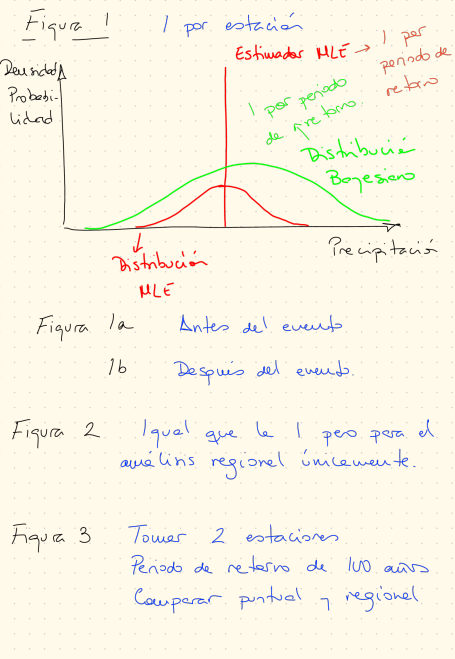

In [13]:
def Figura_1(T_bayes_SD, T_mle_SD,T_mle_value_SD, T_bayes_CD, T_mle_CD,T_mle_value_CD, station, T): 

    title= f'Comparative Analysis of Bayesian vs MLE Distributions Return Period: T{T} \n Station: {station}'

    Fig_SD  = create_comparative_plot(T_bayes_SD, T_mle_SD,T_mle_value_SD, T_bayes_CD, T_mle_CD,T_mle_value_CD, station, T,title)

In [14]:
def Figura_2(estacion_index, station, T, scaler_SD, scaler_CD, T_bayes_scaler_SD, T_mle_scaler_SD,T_mle_value_scaler_SD, T_bayes_scaler_CD, T_mle_scaler_CD,T_mle_value_scaler_CD): 

    # Seleccionar el índice de la estación

    # Normalizar el valor nuevo
    T_mle_value_SD = T_mle_value_scaler_SD*scaler_SD.scale_[estacion_index]+scaler_SD.mean_[estacion_index]

    T_bayes_SD = T_bayes_scaler_SD*scaler_SD.scale_[estacion_index]+scaler_SD.mean_[estacion_index]
    T_mle_SD   = T_mle_scaler_SD*scaler_SD.scale_[estacion_index]+scaler_SD.mean_[estacion_index]

    ######## Ajustes incluyendo DANA #############

    # Normalizar el valor nuevo
    T_mle_value_CD = T_mle_value_scaler_CD*scaler_CD.scale_[estacion_index]+scaler_CD.mean_[estacion_index]

    T_bayes_CD = T_bayes_scaler_CD*scaler_CD.scale_[estacion_index]+scaler_CD.mean_[estacion_index]
    T_mle_CD   = T_mle_scaler_CD*scaler_CD.scale_[estacion_index]+scaler_CD.mean_[estacion_index]

    title= f'Comparative RFA Analysis of Bayesian vs MLE Distributions Return Period: T{T} \n Station: {station}'

    Fig_SD  = create_comparative_plot(T_bayes_SD, T_mle_SD,T_mle_value_SD, T_bayes_CD, T_mle_CD,T_mle_value_CD, station, T, title)

In [15]:
def Figura_3(estacion_index, station, T, title,
            scaler, T_bayes_scaler_Reg, T_mle_scaler_Reg,T_mle_value_scaler_Reg,
            T_bayes_Puntual, T_mle_Puntual,T_mle_value_Puntual): 
    

    # Normalizar el valor nuevo
    T_mle_value_Reg = T_mle_value_scaler_Reg*scaler.scale_[estacion_index]+scaler.mean_[estacion_index]

    T_bayes_Reg = T_bayes_scaler_Reg*scaler.scale_[estacion_index]+scaler.mean_[estacion_index]
    T_mle_Reg   = T_mle_scaler_Reg*scaler.scale_[estacion_index]+scaler.mean_[estacion_index]

    ######## Ajuste Puntual #############

    
    title= f'{title}\n Return Period: T{T} Station: {station}'

    Fig  = create_comparative_put_reg_plot(T_bayes_Reg, T_mle_Reg,T_mle_value_Reg, T_bayes_Puntual, T_mle_Puntual,T_mle_value_Puntual, station, T, title)

In [16]:
def Figura_4(periodos_retorno, precipitaciones_sin_dana_mle, precipitaciones_con_dana_mle,
             precipitaciones_sin_dana_bayes, precipitaciones_con_dana_bayes,title):
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.lines import Line2D
    """
    Genera un gráfico comparativo entre MLE y Bayesian de precipitaciones máximas con y sin DANA
    para diferentes períodos de retorno.

    Parameters:
    ----------
    periodos_retorno : list
        Lista de períodos de retorno (en años).
    precipitaciones_sin_dana_mle : list
        Valores MLE de precipitaciones sin DANA.
    precipitaciones_con_dana_mle : list
        Valores MLE de precipitaciones con DANA.
    precipitaciones_sin_dana_bayes : list
        Valores Bayesian de precipitaciones sin DANA.
    precipitaciones_con_dana_bayes : list
        Valores Bayesian de precipitaciones con DANA.
    """
    # Mapear períodos de retorno a posiciones en el eje Y
    y_positions = np.arange(1, len(periodos_retorno) + 1)

    # Configurar el gráfico
    fig, ax = plt.subplots(figsize=(10, 6))

    # Offset para separar las líneas dentro de cada período
    line_offset = 0.2

    # Crear regiones sombreadas para los períodos de retorno
    for i, y in enumerate(y_positions):
        ax.axhspan(
            y - 0.4, y + 0.4,
            color='lightgrey', alpha=0.3, label='Región' if i == 0 else ""
        )

    # Graficar líneas horizontales para MLE
    for i, y in enumerate(y_positions):
        y_offset = y - line_offset  # Desplazamiento para MLE
        ax.plot(
            [precipitaciones_sin_dana_mle[i], precipitaciones_con_dana_mle[i]],
            [y_offset, y_offset],
            '-',
            color='blue',
            label='MLE' if i == 0 else "",
        )
        ax.plot(
            precipitaciones_sin_dana_mle[i],
            y_offset,
            'o',
            color='blue',
            label='Sin DANA' if i == 0 else "",
        )
        ax.plot(
            precipitaciones_con_dana_mle[i],
            y_offset,
            's',
            color='blue',
            label='Con DANA' if i == 0 else "",
        )

    # Graficar líneas horizontales para Bayesian
    for i, y in enumerate(y_positions):
        y_offset = y + line_offset  # Desplazamiento para Bayes
        ax.plot(
            [precipitaciones_sin_dana_bayes[i], precipitaciones_con_dana_bayes[i]],
            [y_offset, y_offset],
            '-',
            color='cyan',
            label='Bayesian' if i == 0 else "",
        )
        ax.plot(
            precipitaciones_sin_dana_bayes[i],
            y_offset,
            'o',
            color='cyan',
        )
        ax.plot(
            precipitaciones_con_dana_bayes[i],
            y_offset,
            's',
            color='cyan',
        )

    # Etiquetas del eje Y
    ax.set_yticks(y_positions)
    ax.set_yticklabels(periodos_retorno)

    # Etiquetas de los ejes
    ax.set_xlabel('Annual Maximum Daily Precipitation (mm)', fontsize=12)
    ax.set_ylabel('Return Period (years)', fontsize=12)
    ax.set_title(title, fontsize=14)

    # Leyenda personalizada
    custom_lines = [
        Line2D([0], [0], color='blue', lw=2, label='MLE'),
        Line2D([0], [0], color='cyan', lw=2, label='Bayesian'),
        Line2D([0], [0], marker='o', color='black', lw=0, label='Excluding DANA'),
        Line2D([0], [0], marker='s', color='black', lw=0, label='Including DANA'),
    ]
    ax.legend(handles=custom_lines, fontsize=10)

    # Ajustar los límites del eje Y
    ax.set_ylim(0.5, len(y_positions) + 0.5)

    # Configurar cuadrícula
    ax.grid(True, linestyle='--', alpha=0.7)

    # Ajustar diseño y mostrar
    plt.tight_layout()
    plt.show()


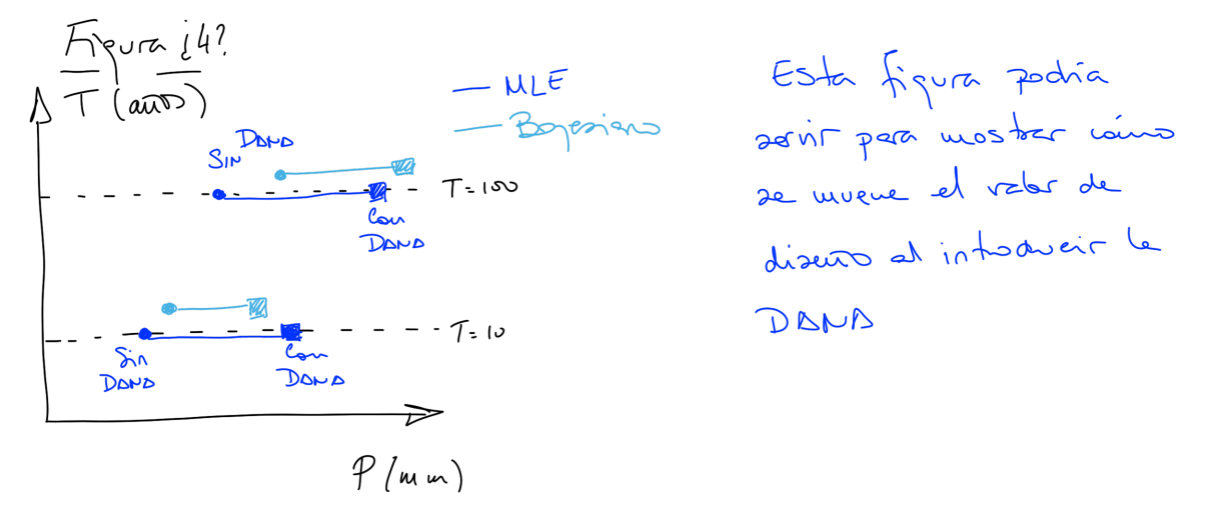

In [17]:
def Figura_5(periodos_retorno, precipitaciones_sin_dana_mle, precipitaciones_con_dana_mle, 
                 periodos_con_dana_mle, precipitaciones_sin_dana_bayes, 
                 precipitaciones_con_dana_bayes, periodos_con_dana_bayes, title,
            savefile=None):
    """
    Genera un gráfico comparativo entre MLE y Bayesian mostrando el impacto con y sin DANA
    con escala logarítmica y posicionamiento mejorado para evitar amontonamiento de texto.

    Parameters:
    ----------
    periodos_retorno : list
        Períodos de retorno T.
    precipitaciones_sin_dana_mle : list
        Precipitaciones sin DANA (MLE).
    precipitaciones_con_dana_mle : list
        Precipitaciones con DANA (MLE).
    periodos_con_dana_mle : list
        Períodos ajustados con DANA (MLE).
    precipitaciones_sin_dana_bayes : list
        Precipitaciones sin DANA (Bayesian).
    precipitaciones_con_dana_bayes : list
        Precipitaciones con DANA (Bayesian).
    periodos_con_dana_bayes : list
        Períodos ajustados con DANA (Bayesian).
    """
    # Configurar la figura
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_title(title, fontsize=12)

    # Establecer escala logarítmica
    ax.set_xscale('log')  # Escala logarítmica para el eje X (precipitación)
    ax.set_yscale('log')  # Escala logarítmica para el eje Y (período de retorno)

    # Parámetros de desplazamiento
    offset_x = 0.03  # Desplazamiento horizontal relativo
    offset_y = 0.15  # Desplazamiento vertical relativo

    

    # Graficar datos Bayesian
    for i, t in enumerate(periodos_retorno):
        # Puntos iniciales y finales
        ax.plot(precipitaciones_sin_dana_bayes[i], t, 'o', color='red', label='Bayesian P' if i == 0 else "")
        ax.plot(precipitaciones_con_dana_bayes[i], t, 's', color='red', label='Bayesian P*' if i == 0 else "")
        ax.plot(precipitaciones_sin_dana_bayes[i], periodos_con_dana_bayes[i], 'x', color='red', label='Bayesian T*' if i == 0 else "")

        # Flechas Bayesian
        ax.annotate(
            '', xy=(precipitaciones_con_dana_bayes[i], t), xytext=(precipitaciones_sin_dana_bayes[i], t),
            arrowprops=dict(arrowstyle='->', color='grey', linestyle='-.', lw=1.5, alpha=0.8)
        )
        ax.annotate(
            '', xy=(precipitaciones_sin_dana_bayes[i], periodos_con_dana_bayes[i]), xytext=(precipitaciones_sin_dana_bayes[i], t),
            arrowprops=dict(arrowstyle='->', color='grey',linestyle='--', lw=1.5, alpha=0.8)
        )

        # Texto para ΔP y ΔT (Bayesian)
        ax.text(
            (precipitaciones_sin_dana_bayes[i] + precipitaciones_con_dana_bayes[i]) / 2,
            t * (1 - offset_y),  # Ajuste vertical dinámico
            f"ΔP={precipitaciones_con_dana_bayes[i] - precipitaciones_sin_dana_bayes[i]:.1f}",
            color='red', fontsize=9, ha='center', va='top'
        )
        ax.text(
            precipitaciones_sin_dana_bayes[i] * (1 + offset_x + 0.015),  # Ajuste horizontal dinámico
            (t + periodos_con_dana_bayes[i]) / 2,
            f"ΔT={periodos_con_dana_bayes[i] - t:.1f}",
            color='red', fontsize=9, ha='center', rotation=90, va='center'
        )

    # Graficar datos MLE
    for i, t in enumerate(periodos_retorno):
        # Puntos iniciales y finales
        ax.plot(precipitaciones_sin_dana_mle[i], t, 'o', color='blue', label='MLE P' if i == 0 else "")
        ax.plot(precipitaciones_con_dana_mle[i], t, 's', color='blue', label='MLE P*' if i == 0 else "")
        ax.plot(precipitaciones_sin_dana_mle[i], periodos_con_dana_mle[i], 'x', color='blue', label='MLE T*' if i == 0 else "")

        # Flechas MLE
        ax.annotate(
            '', xy=(precipitaciones_con_dana_mle[i], t), xytext=(precipitaciones_sin_dana_mle[i], t),
            arrowprops=dict(arrowstyle='->', color='grey', linestyle='-.', lw=1.5, alpha=0.8)
        )
        ax.annotate(
            '', xy=(precipitaciones_sin_dana_mle[i], periodos_con_dana_mle[i]), xytext=(precipitaciones_sin_dana_mle[i], t),
            arrowprops=dict(arrowstyle='->', color='grey', linestyle='--', lw=1.5, alpha=0.8)
        )

        # Texto para ΔP y ΔT (MLE)
        ax.text(
            (precipitaciones_sin_dana_mle[i] + precipitaciones_con_dana_mle[i]) / 2,
            t * (1 + offset_y),  # Ajuste vertical dinámico
            f"ΔP={precipitaciones_con_dana_mle[i] - precipitaciones_sin_dana_mle[i]:.1f}",
            color='blue', fontsize=9, ha='center', va='bottom'
        )
        ax.text(
            precipitaciones_sin_dana_mle[i] * (1 - offset_x),  # Ajuste horizontal dinámico
            (t + periodos_con_dana_mle[i]) / 2,
            f"ΔT={periodos_con_dana_mle[i] - t:.1f}",
            color='blue', fontsize=9, ha='center', rotation=90, va='center'
        )

    # Configurar etiquetas y leyenda
    ax.set_xlabel('Annual Maximum Daily Precipitation (mm)', fontsize=10)
    ax.set_ylabel('Return Period (years)', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Añadir leyenda para las flechas
    gray_arrow = plt.Line2D([0], [0], color='grey',linestyle='-.', lw=1.5, label='ΔP')
    red_arrow = plt.Line2D([0], [0], color='grey',linestyle='--', lw=1.5, label='ΔT')
    handles, labels = ax.get_legend_handles_labels()
    handles.extend([gray_arrow, red_arrow])
    ax.legend(handles=handles, fontsize=8, frameon=True, loc='upper left')

    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, y_max * 1.2)

    # Mostrar gráfico
    plt.tight_layout()
    if savefile is not None:
        from os.path import join as opj
        plt.savefig(opj("output", savefile), dpi=600, bbox_inches='tight')
    plt.show()


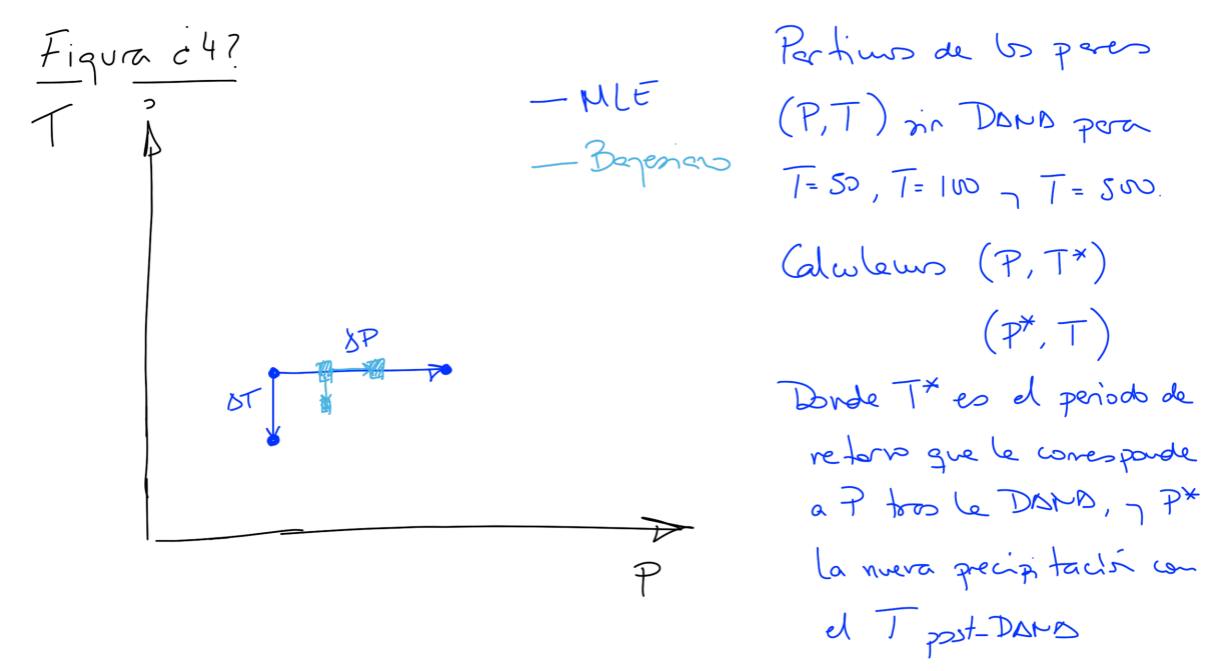

In [18]:
Estaciones = ['8337X','8309X','8414A','8416X','V05','V17','V01','c18m111e01','c16m244e01','c18m109e01','V103']
daily_series = pd.read_csv('./data/Daily_series_conjuntas.csv',index_col=0, parse_dates=True)
daily_series_stations = daily_series.loc[:,Estaciones].resample('D').sum(min_count=1).resample('YE').max(min_count=1)
# daily_series = daily_series.loc[:,['8337X','8319X','8414A','8416X','V05','V17','V01','c18m111e01','c16m244e01']]

100%|██████████| 4000/4000 [00:04<00:00, 812.87it/s]


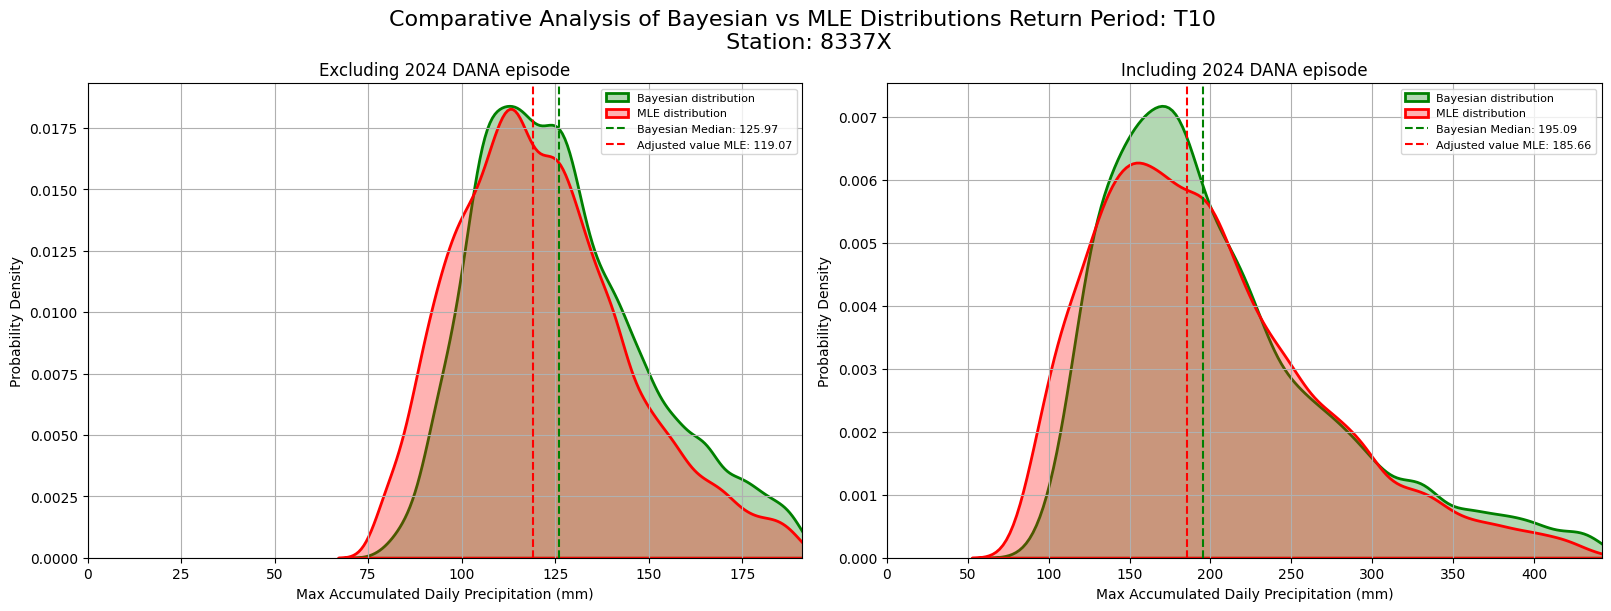

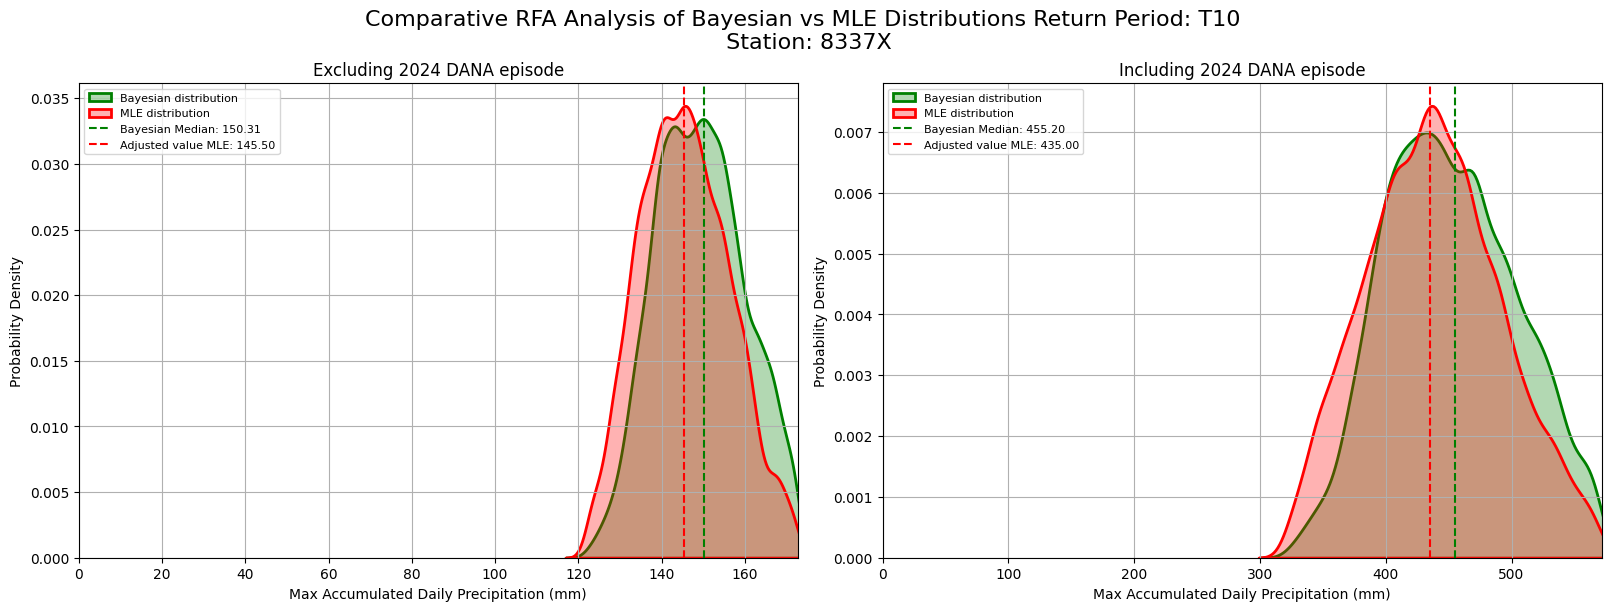

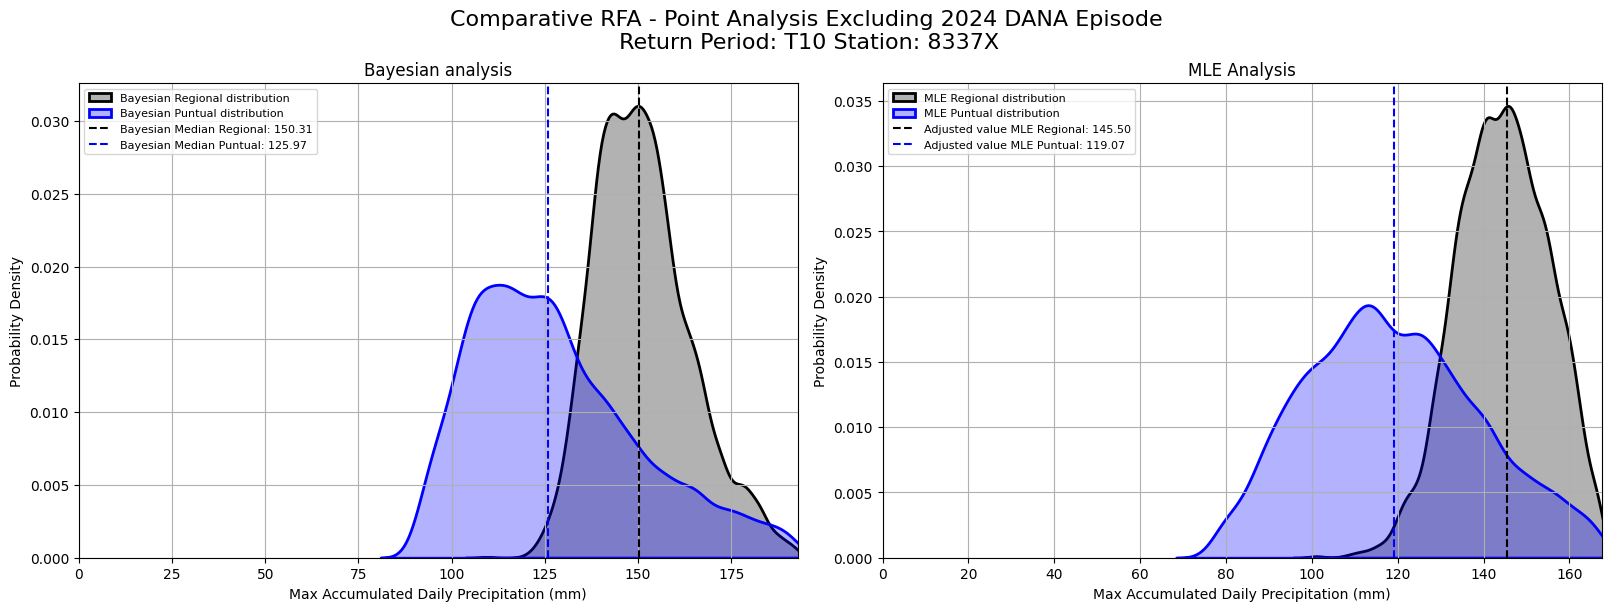

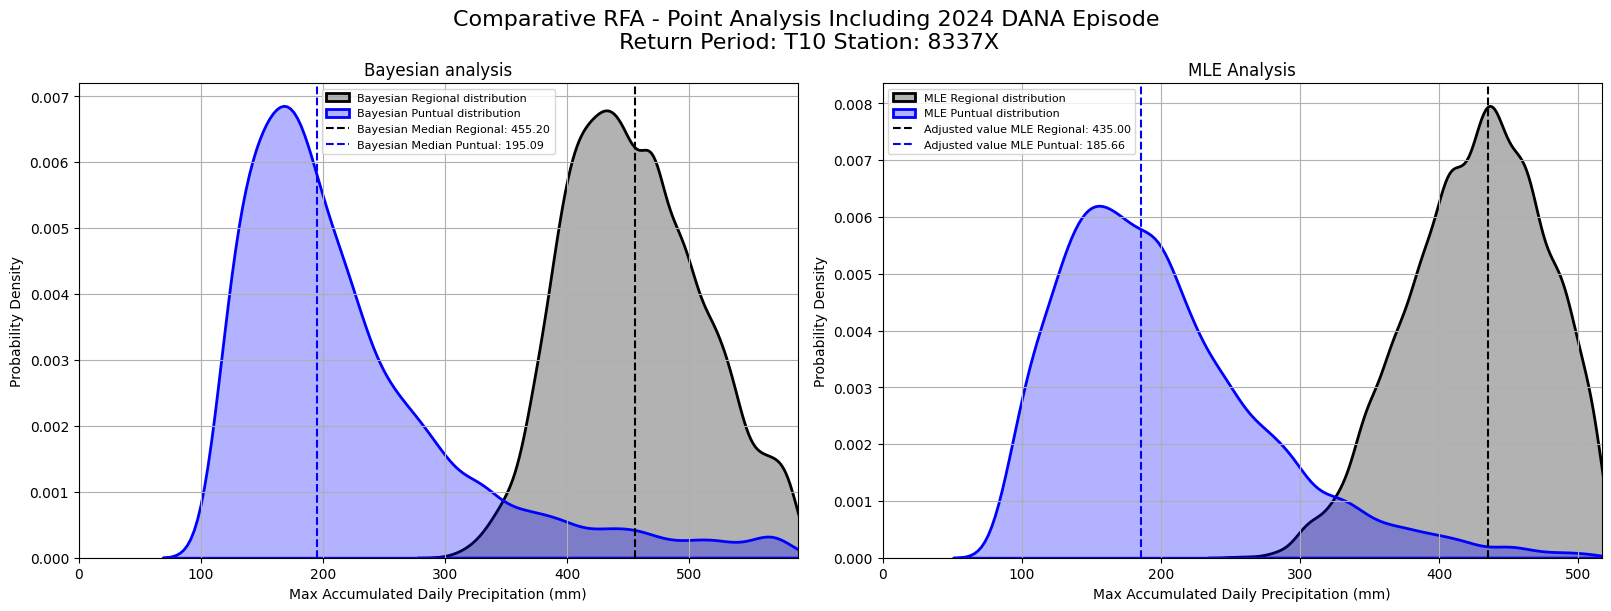

100%|██████████| 4000/4000 [00:05<00:00, 775.78it/s]


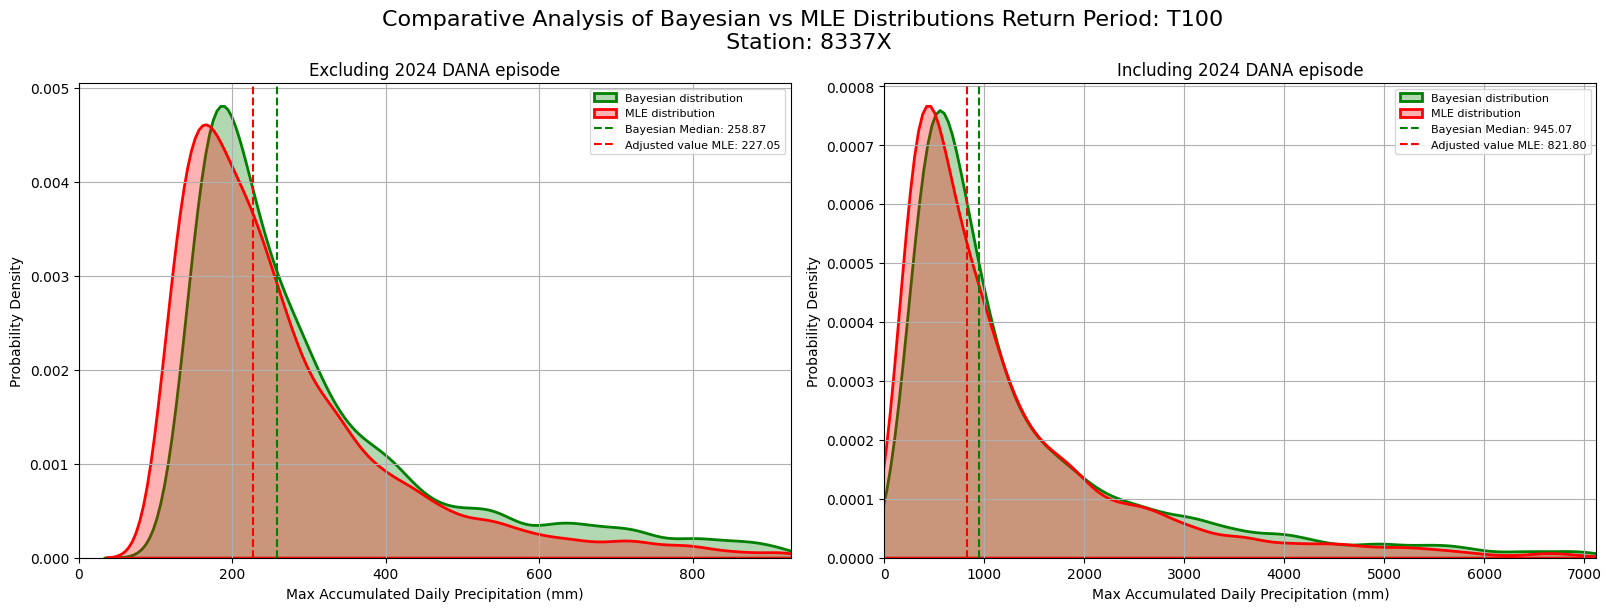

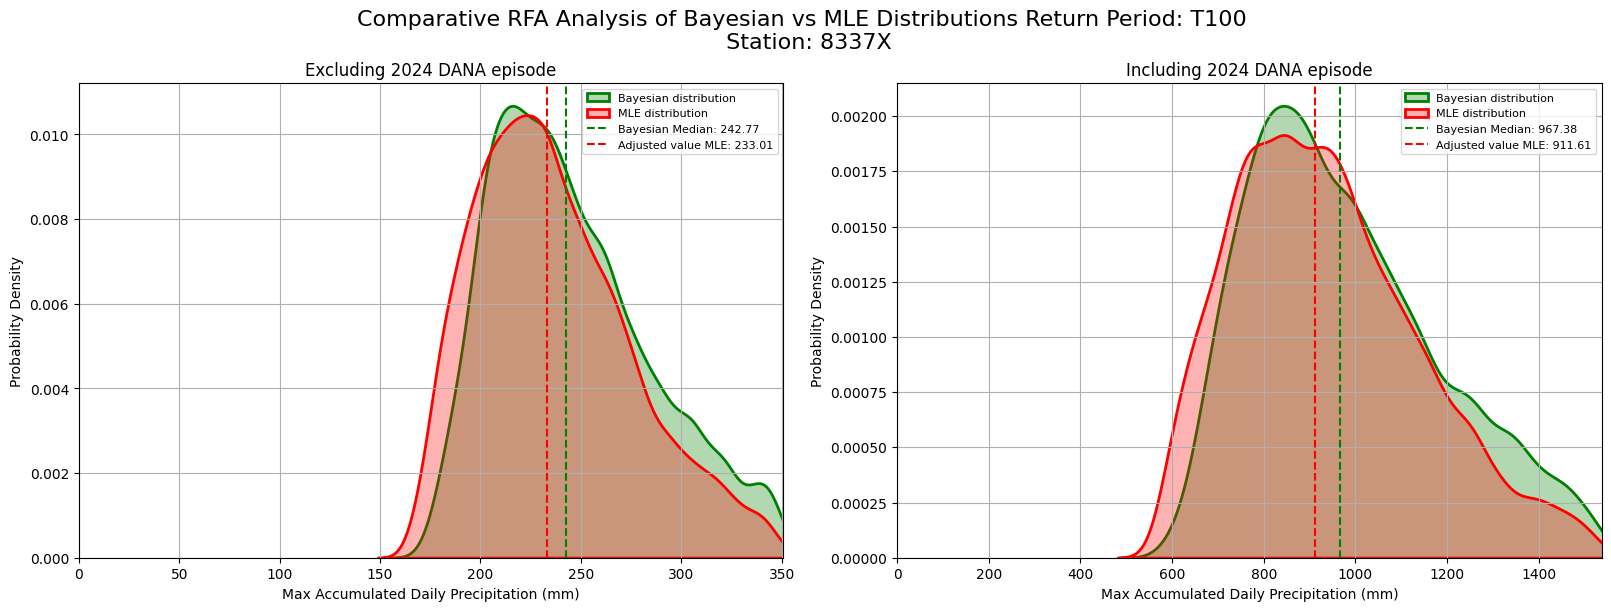

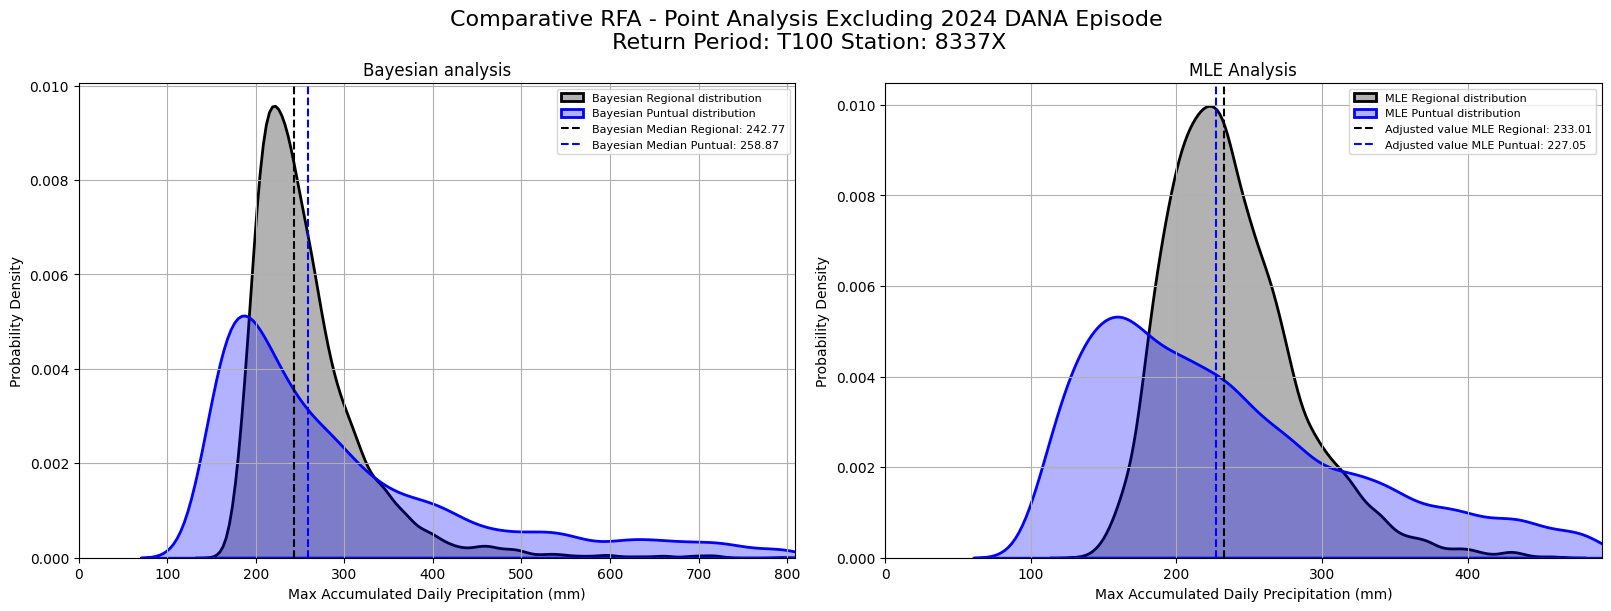

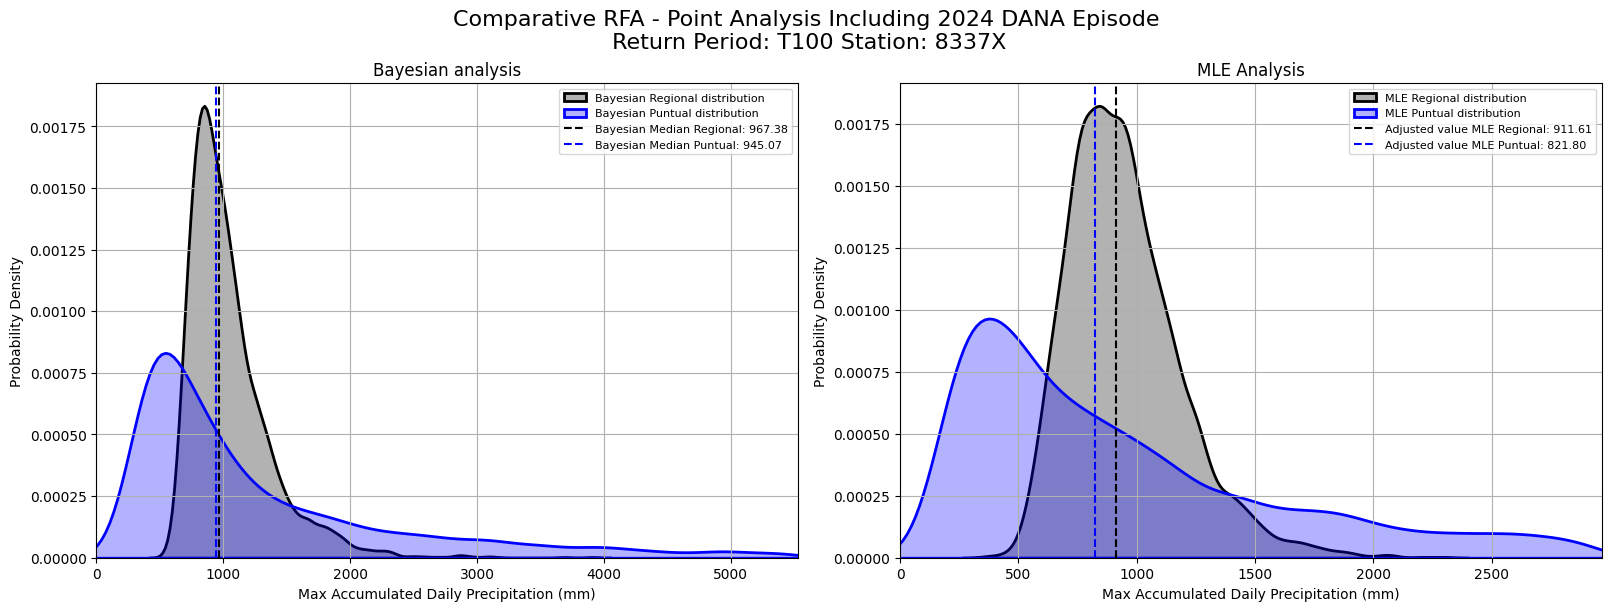

100%|██████████| 4000/4000 [00:05<00:00, 789.18it/s]


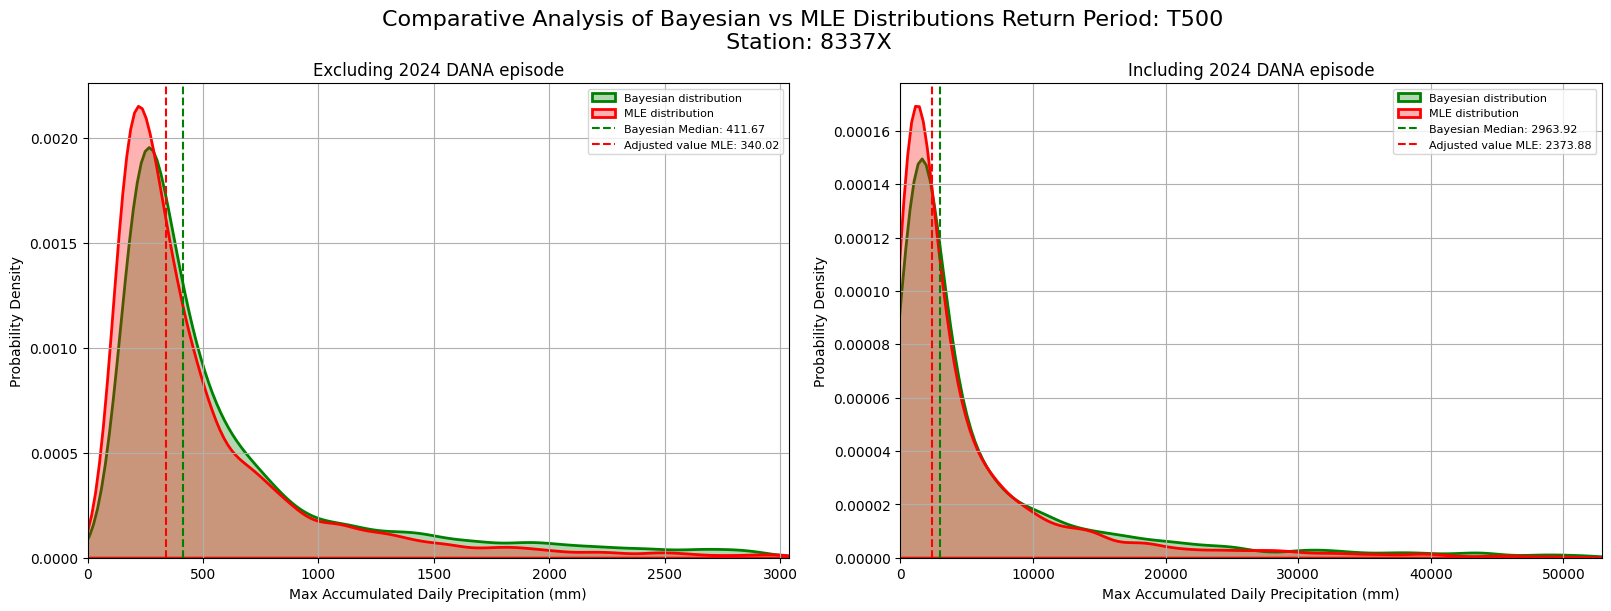

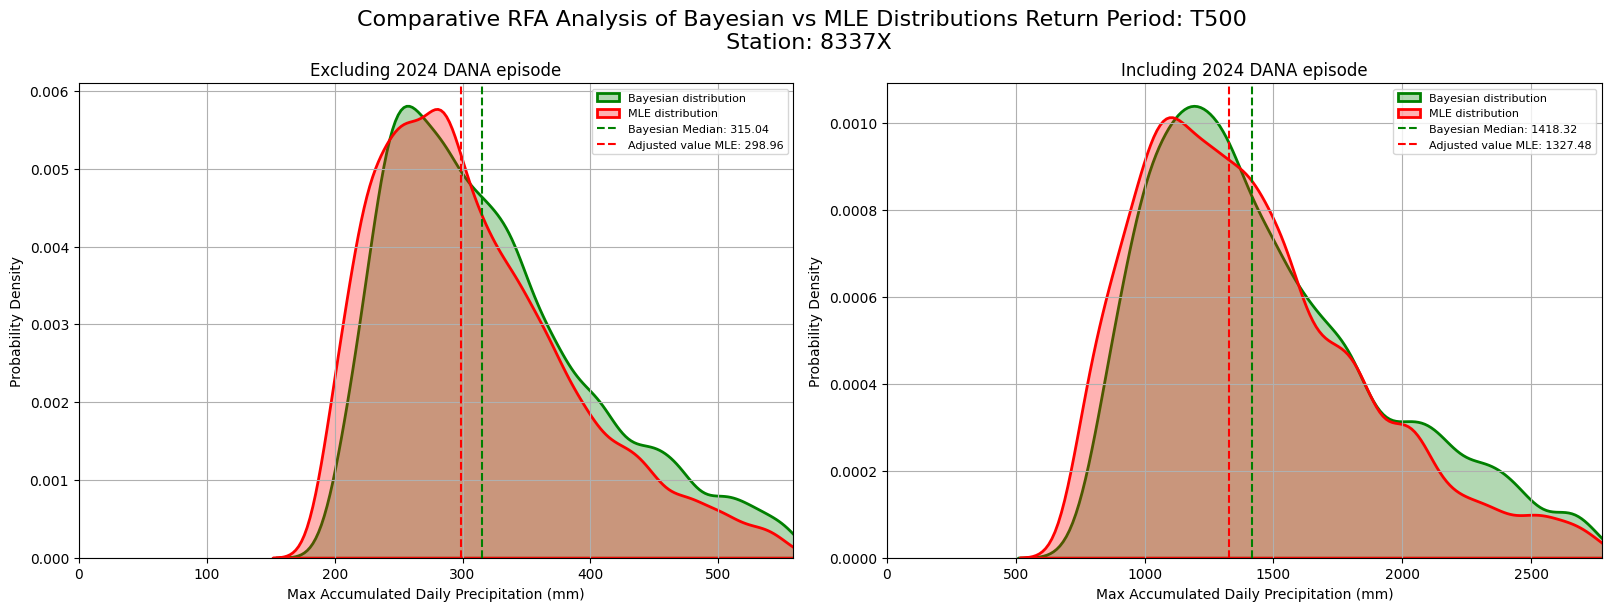

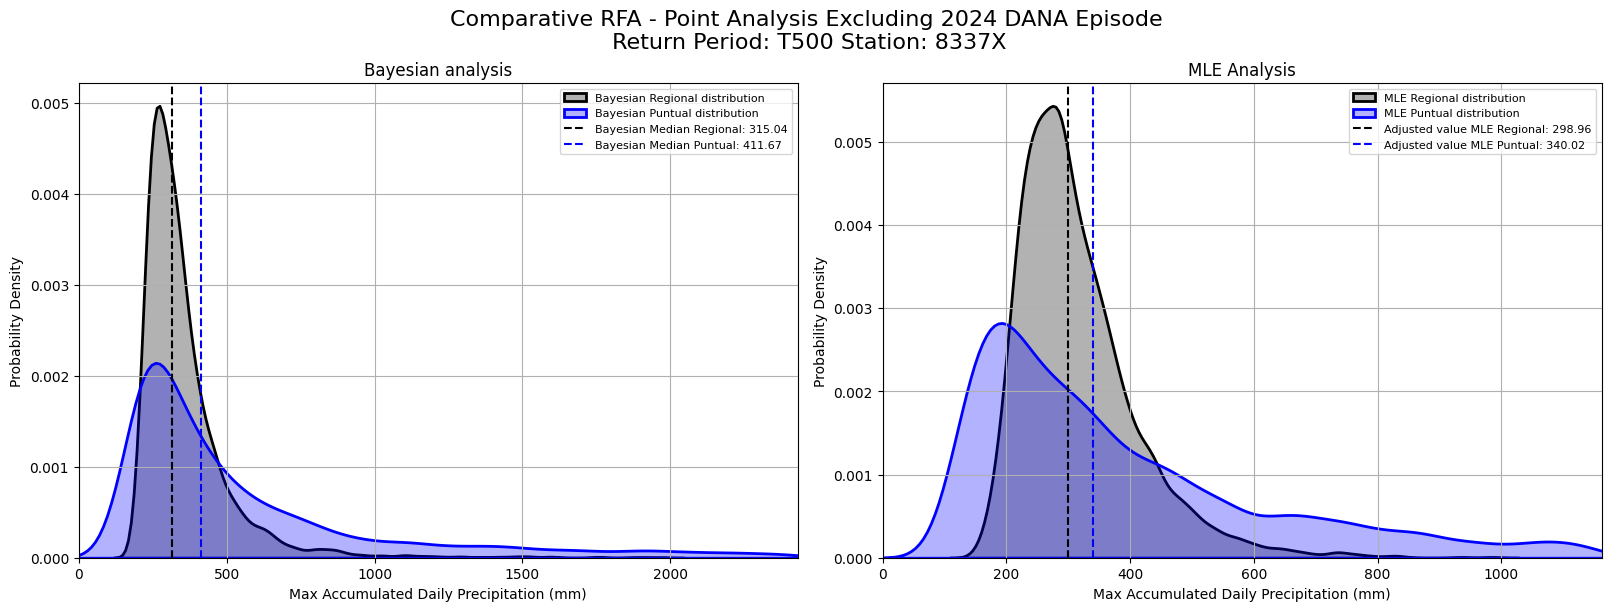

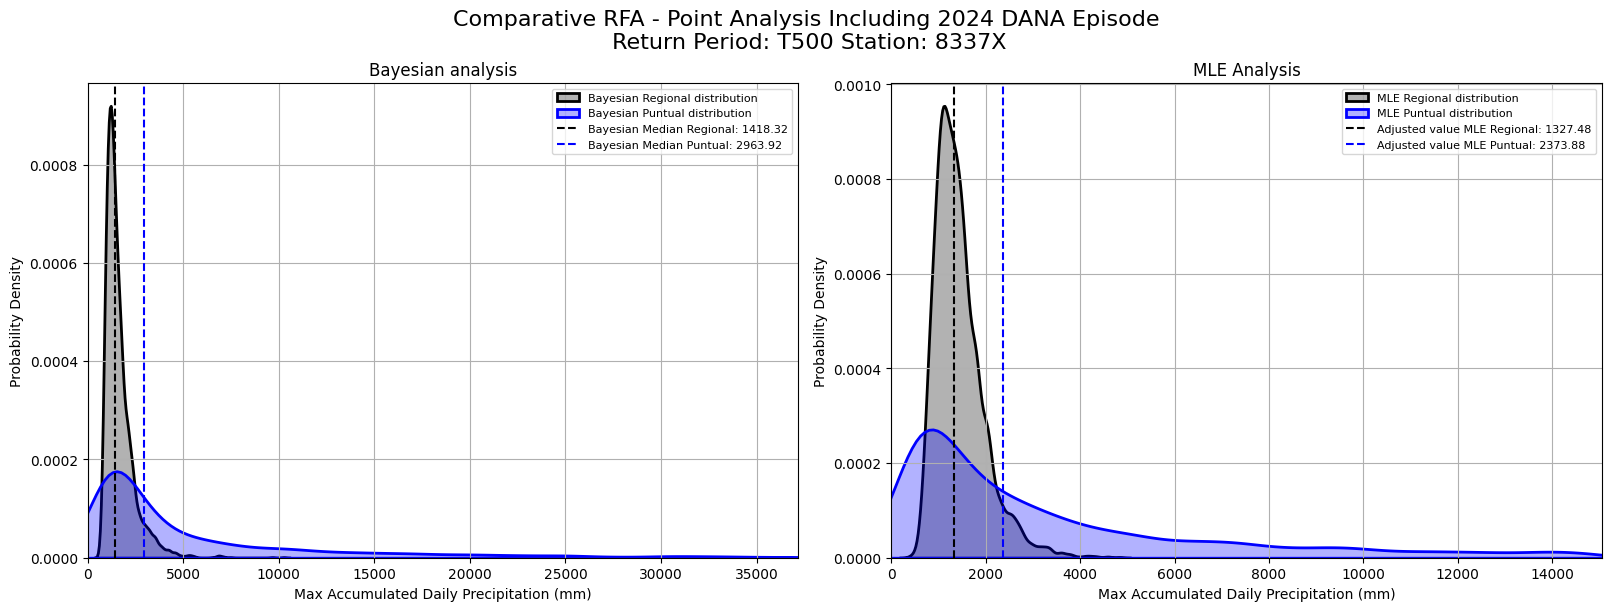

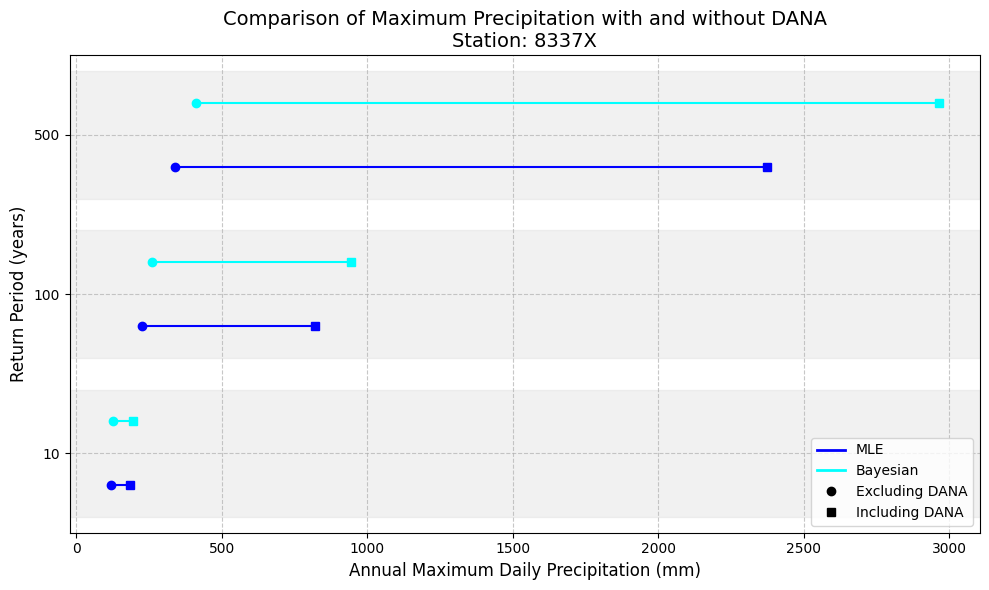

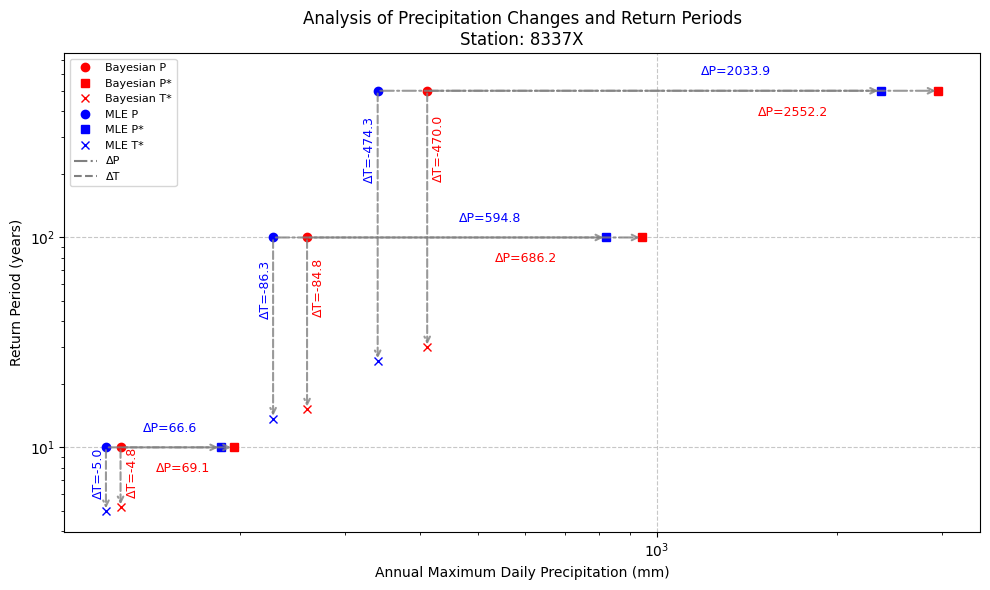

Full results table:
+---------+---------------+----------------+--------------+------------+-------------+--------------+---------+-----------+
| Station | Return Period |      Type      |     DANA     | Bayes_p2_5 | Bayes_p97_5 | Bayes_median |   MLE   | L-Moments |
+---------+---------------+----------------+--------------+------------+-------------+--------------+---------+-----------+
|  8337X  |      10       |     Point      | Without DANA |   92.41    |   263.06    |    125.97    | 119.07  |  119.58   |
|  8337X  |      10       |     Point      |  With DANA   |   114.33   |   742.47    |    195.09    | 185.66  |  165.35   |
|  8337X  |      10       | Regional (RFA) | Without DANA |   130.42   |   187.84    |    150.31    |  145.5  |  146.86   |
|  8337X  |      10       | Regional (RFA) |  With DANA   |   358.83   |    643.1    |    455.2     |  435.0  |  437.05   |
|  8337X  |      100      |     Point      | Without DANA |   141.72   |   1982.55   |    258.87    | 227.05  | 

In [20]:
results = []

daily_series_CD = daily_series_stations.resample('D').sum(min_count=1).resample('YE').max(min_count=1)
daily_series_SD = daily_series_stations.iloc[:-1].resample('D').sum(min_count=1).resample('YE').max(min_count=1)


theta_mle_scaler_SD,theta_lm_scaler_SD, theta_sim_scaler_SD, fit_escaler_SD, scaler_SD =adjust_values_bayes_mle_REGIONAL(daily_series_SD,nsim=1000)
theta_mle_scaler_CD,theta_lm_scaler_CD, theta_sim_scaler_CD, fit_escaler_CD, scaler_CD =adjust_values_bayes_mle_REGIONAL(daily_series_CD,nsim=1000)

return_periods = [10, 100, 500]

for st in ['8337X']:#,'8309X','8414A','8416X','V05','V17','V01','c18m111e01','c16m244e01','c18m109e01','V103']:
    station_index = daily_series_stations.columns.get_loc(st)

    data_SD = daily_series_SD.loc[:, st].dropna().values.astype(float)  # Without DANA
    data_CD = daily_series_CD.loc[:, st].dropna().values.astype(float)  # With DANA
    theta_mle_SD, theta_lm_SD, theta_sim_SD, fit_SD = adjust_values_bayes_mle(data_SD, nsim=1000)
    theta_mle_CD, theta_lm_CD, theta_sim_CD, fit_CD = adjust_values_bayes_mle(data_CD, nsim=1000)

    P_T_mle_SD, P_T_bayes_SD = [], []
    P_T_mle_CD, P_T_bayes_CD = [], []
    T_P_mle, T_P_bayes = [], []

    for T in return_periods:
        T_bayes_SD, T_mle_SD, T_mle_value_SD, T_lm_value_SD = calculate_value_asociate_RP(theta_mle_SD, theta_lm_SD, theta_sim_SD, fit_SD, T)
        T_bayes_CD, T_mle_CD, T_mle_value_CD, T_lm_value_CD = calculate_value_asociate_RP(theta_mle_CD, theta_lm_CD, theta_sim_CD, fit_CD, T)

        T_bayes_scaler_SD, T_mle_scaler_SD, T_mle_value_scaler_SD, T_lm_value_scaler_SD = calculate_value_asociate_RP(theta_mle_scaler_SD, theta_lm_scaler_SD, theta_sim_scaler_SD, fit_escaler_SD, T)
        T_bayes_scaler_CD, T_mle_scaler_CD, T_mle_value_scaler_CD, T_lm_value_scaler_CD = calculate_value_asociate_RP(theta_mle_scaler_CD, theta_lm_scaler_CD, theta_sim_scaler_CD, fit_escaler_CD, T)

        Figura_1(T_bayes_SD, T_mle_SD, T_mle_value_SD, T_bayes_CD, T_mle_CD, T_mle_value_CD, st, T)
        Figura_2(station_index, st, T, scaler_SD, scaler_CD, T_bayes_scaler_SD, T_mle_scaler_SD, T_mle_value_scaler_SD, T_bayes_scaler_CD, T_mle_scaler_CD, T_mle_value_scaler_CD)
        Figura_3(station_index, st, T, 'Comparative RFA - Point Analysis Excluding 2024 DANA Episode',
                 scaler_SD, T_bayes_scaler_SD, T_mle_scaler_SD, T_mle_value_scaler_SD,
                 T_bayes_SD, T_mle_SD, T_mle_value_SD)
        Figura_3(station_index, st, T, 'Comparative RFA - Point Analysis Including 2024 DANA Episode',
                 scaler_CD, T_bayes_scaler_CD, T_mle_scaler_CD, T_mle_value_scaler_CD,
                 T_bayes_CD, T_mle_CD, T_mle_value_CD)

        P_T_mle_SD.append(T_mle_value_SD)
        P_T_mle_CD.append(T_mle_value_CD)
        P_T_bayes_SD.append(np.median(T_bayes_SD))
        P_T_bayes_CD.append(np.median(T_bayes_CD))

        T_P_mle.append(calculate_return_period(theta_mle_CD, fit_CD, T_mle_value_SD)[1])
        T_P_bayes.append(calculate_return_period(theta_mle_CD, fit_CD, np.median(T_bayes_SD))[0])

        # Function to extract percentiles from Bayesian distribution
        def get_bayes_percentiles(dist):
            return {
                'p2_5': np.percentile(dist, 2.5),
                'median': np.median(dist),
                'p97_5': np.percentile(dist, 97.5)
            }

        # Results for each combination
        bayes_SD = get_bayes_percentiles(T_bayes_SD)
        bayes_CD = get_bayes_percentiles(T_bayes_CD)

        # Regional Without DANA
        T_mle_value_SD_Reg = T_mle_value_scaler_SD * scaler_SD.scale_[station_index] + scaler_SD.mean_[station_index]
        T_lm_value_SD_Reg = T_lm_value_scaler_SD * scaler_SD.scale_[station_index] + scaler_SD.mean_[station_index]
        T_bayes_SD_Reg = T_bayes_scaler_SD * scaler_SD.scale_[station_index] + scaler_SD.mean_[station_index]
        bayes_scaler_SD = get_bayes_percentiles(T_bayes_SD_Reg)

        # Regional With DANA
        T_mle_value_CD_Reg = T_mle_value_scaler_CD * scaler_CD.scale_[station_index] + scaler_CD.mean_[station_index]
        T_lm_value_CD_Reg = T_lm_value_scaler_CD * scaler_CD.scale_[station_index] + scaler_CD.mean_[station_index]
        T_bayes_CD_Reg = T_bayes_scaler_CD * scaler_CD.scale_[station_index] + scaler_CD.mean_[station_index]
        bayes_scaler_CD = get_bayes_percentiles(T_bayes_CD_Reg)

        # Store results
        results.extend([
            {'Station': st, 'Return Period': T, 'Type': 'Point', 'DANA': 'Without DANA',
             'Bayes_p2_5': bayes_SD['p2_5'], 'Bayes_median': bayes_SD['median'], 'Bayes_p97_5': bayes_SD['p97_5'],
             'MLE': T_mle_value_SD, 'L-Moments': T_lm_value_SD},

            {'Station': st, 'Return Period': T, 'Type': 'Point', 'DANA': 'With DANA',
             'Bayes_p2_5': bayes_CD['p2_5'], 'Bayes_median': bayes_CD['median'], 'Bayes_p97_5': bayes_CD['p97_5'],
             'MLE': T_mle_value_CD, 'L-Moments': T_lm_value_CD},

            {'Station': st, 'Return Period': T, 'Type': 'Regional (RFA)', 'DANA': 'Without DANA',
             'Bayes_p2_5': bayes_scaler_SD['p2_5'], 'Bayes_median': bayes_scaler_SD['median'], 'Bayes_p97_5': bayes_scaler_SD['p97_5'],
             'MLE': T_mle_value_SD_Reg, 'L-Moments': T_lm_value_SD_Reg},

            {'Station': st, 'Return Period': T, 'Type': 'Regional (RFA)', 'DANA': 'With DANA',
             'Bayes_p2_5': bayes_scaler_CD['p2_5'], 'Bayes_median': bayes_scaler_CD['median'], 'Bayes_p97_5': bayes_scaler_CD['p97_5'],
             'MLE': T_mle_value_CD_Reg, 'L-Moments': T_lm_value_CD_Reg}
        ])

    Figura_4(return_periods, P_T_mle_SD, P_T_mle_CD, P_T_bayes_SD, P_T_bayes_CD,
             title=f'Comparison of Maximum Precipitation with and without DANA\nStation: {st}')
    Figura_5(return_periods, P_T_mle_SD, P_T_mle_CD, T_P_mle, P_T_bayes_SD, P_T_bayes_CD, T_P_bayes,
             title=f'Analysis of Precipitation Changes and Return Periods\nStation: {st}',
            savefile="Changes-in-P-and-T.jpg")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Reorder columns
column_order = ['Station', 'Return Period', 'Type', 'DANA', 'Bayes_p2_5', 'Bayes_p97_5', 'Bayes_median', 'MLE', 'L-Moments']
results_df = results_df[column_order]

# Round decimals
results_df = results_df.round(2)

# Display table
print("Full results table:")
print(tabulate(results_df, headers='keys', tablefmt='pretty', showindex=False))
results_df.to_csv('./Resultados_RP/resultados_regional_pequeño.csv', index=False)